In [17]:
# !unzip archive.zip

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [19]:
train_data_transform = transforms.Compose([
      transforms.Resize((128, 128)),
      # transforms.RandomHorizontalFlip(),
      # transforms.RandomRotation(10),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_data_transform = transforms.Compose([
      transforms.Resize((128, 128)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [20]:
train_dataset = datasets.ImageFolder("dataset/train", transform=train_data_transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=test_data_transform)

In [21]:
len(train_dataset), len(test_dataset)

(20000, 12461)

In [22]:
train_dataset[3][0].size()

torch.Size([3, 128, 128])

In [23]:
train_data_loader = DataLoader(train_dataset, shuffle=True, batch_size=128, pin_memory=True)
test_data_loader = DataLoader(test_dataset, shuffle=True, batch_size=128, pin_memory=True)

In [24]:
images, labels = next(iter(train_data_loader))

print("Batch shape:", images.shape)   # e.g. torch.Size([128, 3, 224, 224])
print("Labels shape:", labels.shape)  # e.g. torch.Size([128])
print("Labels:", labels)

Batch shape: torch.Size([128, 3, 128, 128])
Labels shape: torch.Size([128])
Labels: tensor([0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0,
        1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
        1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1,
        1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 0, 0])


In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from torch.nn.modules.conv import Conv2d
class CNN(nn.Module):

  def __init__(self):
    super().__init__()

    self.features = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding="same"),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding="same"),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding="same"),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(128 * 16 * 16, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(64, 2)
    )


  def forward(self, x):
    X = self.features(x)
    X = self.classifier(X)
    return X

In [27]:
model = CNN().to(device)

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [29]:
for epoch in range(10):

  total_loss = 0
  for img, label in train_data_loader:
    img, label = img.to(device), label.to(device)

    optimizer.zero_grad()

    output = model(img)
    loss = criterion(output, label)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
  avg_loss = total_loss / len(train_data_loader)
  print(f"Epoch: {epoch+1}, Loss: {avg_loss}")

Epoch: 1, Loss: 0.8211481423135016
Epoch: 2, Loss: 0.6068788736489168
Epoch: 3, Loss: 0.5321551792940517
Epoch: 4, Loss: 0.4748927612972867
Epoch: 5, Loss: 0.4345151745969323
Epoch: 6, Loss: 0.40300645674489866
Epoch: 7, Loss: 0.38282166639710685
Epoch: 8, Loss: 0.3648472868712844
Epoch: 9, Loss: 0.34328403281178443
Epoch: 10, Loss: 0.32973005285688267


In [30]:
model.eval()
images, labels = next(iter(test_data_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    probs   = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, dim=1)
    print(confs, preds, labels)

tensor([0.9932, 0.9334, 0.9537, 0.9708, 0.9570, 0.9761, 0.9708, 0.9666, 0.9913,
        0.5325, 0.6851, 0.5651, 0.7702, 0.9785, 0.6115, 0.8935, 0.9114, 0.9965,
        0.9638, 0.8875, 0.8787, 0.9741, 0.9982, 0.9197, 0.9584, 0.9941, 0.9587,
        0.9334, 0.8238, 0.9113, 0.9784, 0.7398, 0.9920, 0.8902, 0.8326, 0.9497,
        0.9767, 0.8905, 0.9980, 0.9913, 0.9196, 0.5455, 0.9960, 0.9671, 0.9505,
        0.8658, 0.9461, 0.9852, 0.9949, 0.9356, 0.9719, 0.9839, 0.7622, 0.9870,
        0.9920, 0.5439, 0.9495, 0.9883, 0.9692, 0.9394, 0.9939, 0.7130, 0.9883,
        0.9655, 0.6506, 0.9993, 0.9395, 0.9690, 0.9926, 0.9927, 0.9044, 0.9844,
        0.9992, 0.9980, 0.9876, 0.8581, 0.9979, 0.6549, 0.9254, 0.9903, 0.9942,
        0.9852, 0.8953, 0.6164, 0.9417, 0.9567, 0.9875, 0.9698, 0.8715, 0.8667,
        0.9583, 0.9927, 0.9952, 0.8880, 0.9417, 0.7920, 0.9968, 0.9934, 0.7578,
        0.9453, 0.6271, 0.9882, 0.9968, 0.5170, 0.9977, 0.8024, 0.5779, 0.8194,
        0.8559, 0.8616, 0.6878, 0.9486, 

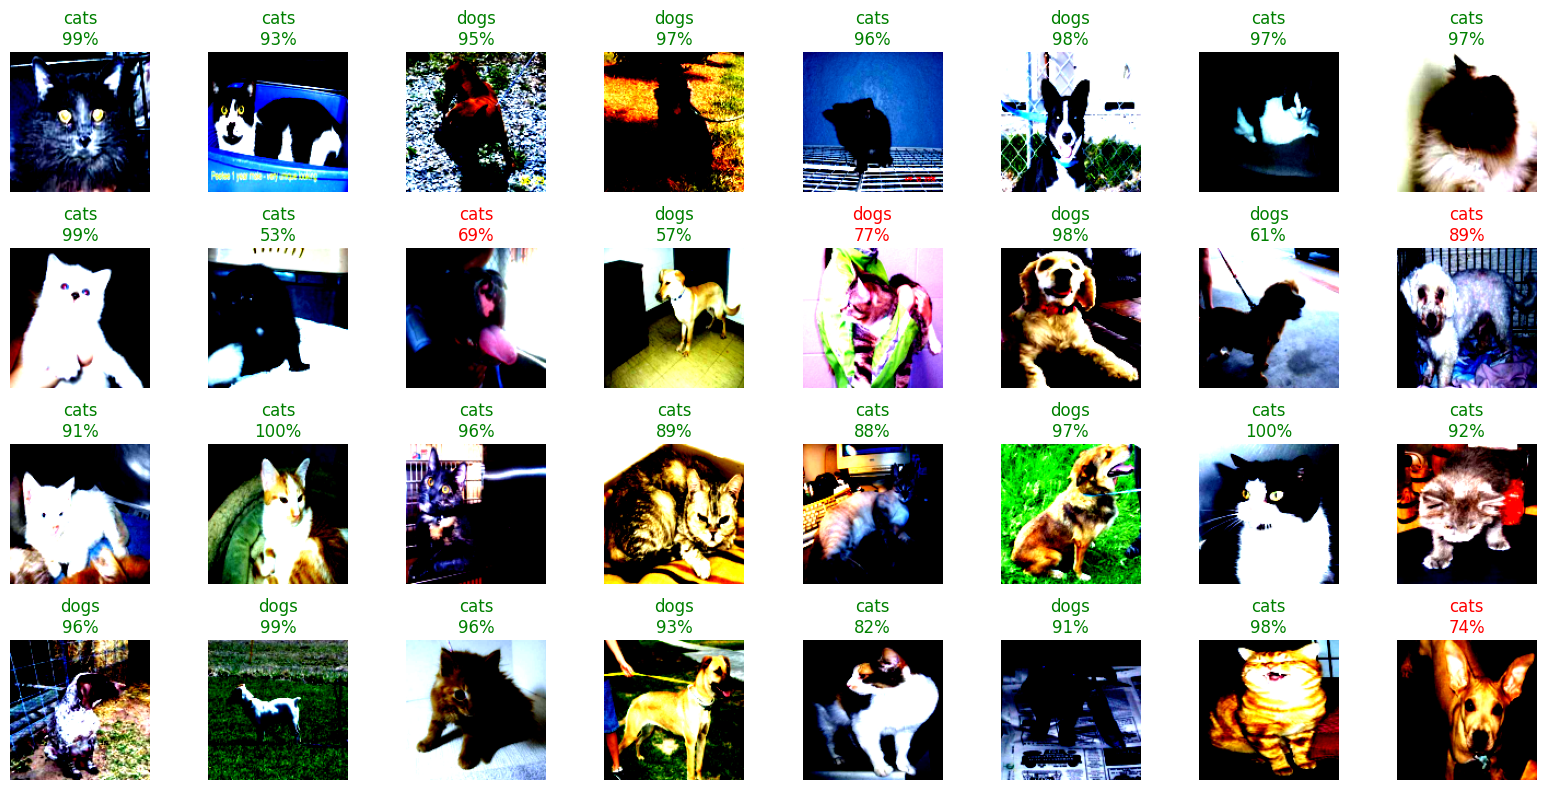

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0).cpu()
    ax.imshow(img)
    correct = preds[i] == labels[i]
    ax.set_title(
        f"{train_dataset.classes[preds[i]]}\n{confs[i]*100:.0f}%",
        color="green" if correct else "red"   # green=correct, red=wrong
    )
    ax.axis("off")
plt.tight_layout()
plt.show()